# Export HK mask
- This script is used to export HK mask for simulation output.

In [20]:
import numpy as np
import xarray as xr
import geopandas as gpd
from shapely.geometry import Point
import os
from shapely.geometry import Polygon
from pyproj import CRS
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
home_path = '/gws/nopw/j04/duicv/yuansun/'
ds_surf = xr.open_dataset(f"{home_path}0_wrf-cstm_GM-HK/HK/surface_data/usurf/Usurf_surfdata_HK_1.2x1.2_SSP5-8.5_2035_78pfts_c250811.nc")
gdf_hk = gpd.read_file('shapefiles/Hong_Kong_18_Districts/HKDistrict18.shp')
gdf_hk = gdf_hk.to_crs("EPSG:4326")
output_filename = 'mask_HK.nc'
output_filename_lat_lon = 'mask_HK_lat_lon.nc'

In [2]:
crs = gdf_hk.crs
print(crs)
gdf_hk

EPSG:4326


,ID,CNAME,CNAME_S,ENAME,geometry
0,1.0,黃大仙區,黄大仙区,WONG TAI SIN,"POLYGON ((114.17942 22.34905, 114.17946 22.349..."
1,6.0,九龍城區,九龙城区,KOWLOON CITY,"MULTIPOLYGON (((114.177 22.34904, 114.17702 22..."
2,7.0,觀塘區,观塘区,KWUN TONG,"POLYGON ((114.24371 22.2862, 114.2437 22.28613..."
3,8.0,西貢區,西贡区,SAI KUNG,"MULTIPOLYGON (((114.22112 22.35318, 114.22114 ..."
4,11.0,北區,北区,NORTH,"MULTIPOLYGON (((114.33576 22.51003, 114.33576 ..."
5,13.0,中西區,中西区,CENTRAL & WESTERN,"MULTIPOLYGON (((114.14562 22.29045, 114.1499 2..."
6,14.0,灣仔區,湾仔区,WAN CHAI,"MULTIPOLYGON (((114.20012 22.27387, 114.20047 ..."
7,15.0,東區,东区,EASTERN,"POLYGON ((114.24738 22.25339, 114.24733 22.253..."
8,17.0,屯門區,屯门区,TUEN MUN,"MULTIPOLYGON (((113.93745 22.42638, 113.93765 ..."
9,18.0,元朗區,元朗区,YUEN LONG,"MULTIPOLYGON (((113.93832 22.42696, 113.93843 ..."


<Axes: >

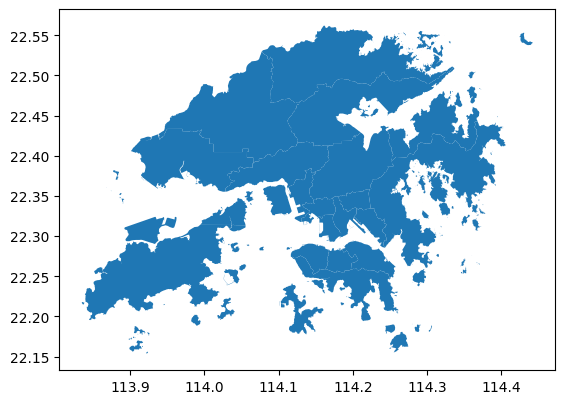

In [40]:
gdf_hk.plot()

In [5]:
hk_boundary = gdf_hk.union_all()
bounds = np.round(hk_boundary.bounds, 2)
bounds

array([113.84,  22.15, 114.44,  22.56])

In [6]:
hk_proj = gdf_hk.to_crs(epsg=2326)
# Compute area in m²
area_m2 = hk_proj.union_all().area
# Convert to km²
area_km2 = area_m2 / 1e6
print("Area (km²):", np.round(area_km2, 2))

Area (km²): 1107.59


In [7]:
ds_domain = xr.open_dataset("../surface_data/domain.lnd.wrf2clm_lnd_noneg_wrf2clm_ocn_noneg.250815.nc")
ds_domain

<xarray.Dataset> Size: 360kB
Dimensions:  (nj: 60, ni: 60, nv: 4)
Coordinates:
    xc       (nj, ni) float64 29kB ...
    yc       (nj, ni) float64 29kB ...
Dimensions without coordinates: nj, ni, nv
Data variables:
    xv       (nj, ni, nv) float64 115kB ...
    yv       (nj, ni, nv) float64 115kB ...
    mask     (nj, ni) int32 14kB ...
    area     (nj, ni) float64 29kB ...
    frac     (nj, ni) float64 29kB ...
Attributes:
    title:               CESM domain data:
    Conventions:         CF-1.0
    source_code:         SVN $Id: gen_domain.F90 65202 2014-11-06 21:07:45Z m...
    SVN_url:              $URL: https://svn-ccsm-models.cgd.ucar.edu/tools/ma...
    Compiler_Optimized:  TRUE
    history:             created by yuansun, 2025-08-15 18:03:51
    source:              /home/yuansun/wrf/runs/TranUrbAlb_HK/configuration/C...
    map_domain_a:        /home/yuansun/wrf/runs/TranUrbAlb_HK/configuration/C...
    map_domain_b:        /home/yuansun/wrf/runs/TranUrbAlb_HK/configuration/C...
    map_grid_file_ocn:   /home/yuansun/wrf/runs/TranUrbAlb_HK/configuration/C...
    map_grid_file_atm:   /home/yuansun/wrf/runs/TranUrbAlb_HK/configuration/C...

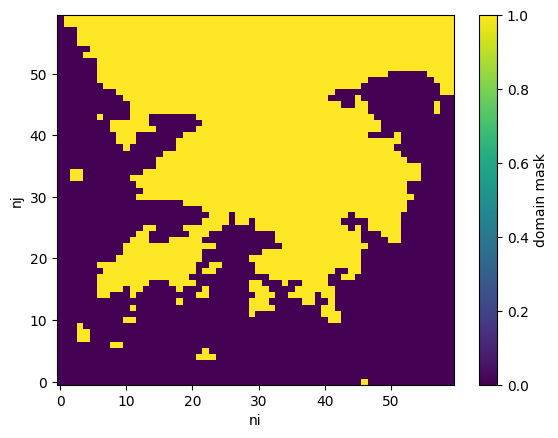

In [6]:
ds_domain['mask'].plot()

In [8]:
grid_cells = []

mask_vals = ds_domain['mask'].values
xv = ds_domain['xv'].values  # shape (nj, ni, 4)
yv = ds_domain['yv'].values

for j in range(ds_domain.dims['nj']):
    for i in range(ds_domain.dims['ni']):
        xcell = xv[j, i, :]
        ycell = yv[j, i, :]
        # handle wrap-around
        xcell = np.where(xcell > 180, xcell - 360, xcell)
        # make polygon from 4 corners
        poly = Polygon(zip(xcell, ycell))
        grid_cells.append(poly)
# build GeoDataFrame
gdf_mesh_hk = gpd.GeoDataFrame(
    geometry=grid_cells,
    data={'mask': mask_vals.flatten()},
    crs=CRS.from_epsg(4326)
)
gdf_mesh_hk

/tmp/ipykernel_535845/1842432867.py:7: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for j in range(ds_domain.dims['nj']):
/tmp/ipykernel_535845/1842432867.py:8: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds_domain.dims['ni']):


,mask,geometry
0,0,"POLYGON ((113.78356 22.05299, 113.79513 22.053..."
1,0,"POLYGON ((113.79513 22.05328, 113.8067 22.0535..."
2,0,"POLYGON ((113.8067 22.05357, 113.81824 22.0538..."
3,0,"POLYGON ((113.81824 22.05387, 113.82979 22.054..."
4,0,"POLYGON ((113.82979 22.05417, 113.84135 22.054..."
...,...,...
3595,1,"POLYGON ((114.40215 22.70011, 114.41374 22.700..."
3596,1,"POLYGON ((114.41374 22.70037, 114.42534 22.700..."
3597,1,"POLYGON ((114.42534 22.70064, 114.43694 22.700..."
3598,1,"POLYGON ((114.43694 22.7009, 114.44852 22.7011..."


<Axes: >

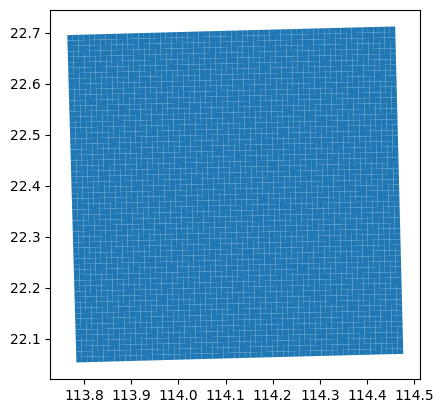

In [7]:
gdf_mesh_hk.plot()

In [9]:
gdf_mesh_hk["intersects_hk"] = gdf_mesh_hk.intersects(gdf_hk.union_all())
gdf_mesh_hk

,mask,geometry,intersects_hk
0,0,"POLYGON ((113.78356 22.05299, 113.79513 22.053...",False
1,0,"POLYGON ((113.79513 22.05328, 113.8067 22.0535...",False
2,0,"POLYGON ((113.8067 22.05357, 113.81824 22.0538...",False
3,0,"POLYGON ((113.81824 22.05387, 113.82979 22.054...",False
4,0,"POLYGON ((113.82979 22.05417, 113.84135 22.054...",False
...,...,...,...
3595,1,"POLYGON ((114.40215 22.70011, 114.41374 22.700...",False
3596,1,"POLYGON ((114.41374 22.70037, 114.42534 22.700...",False
3597,1,"POLYGON ((114.42534 22.70064, 114.43694 22.700...",False
3598,1,"POLYGON ((114.43694 22.7009, 114.44852 22.7011...",False


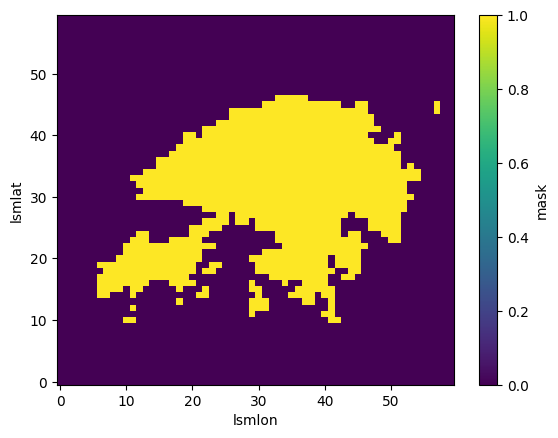

In [10]:
lat = ds_surf['LATIXY'][:, 0].values
lon = ds_surf['LONGXY'][0, :].values
lon_180 = np.where(lon > 180, lon - 360, lon)
lon_grid, lat_grid = np.meshgrid(lon_180, lat)
hk_domain = (gdf_mesh_hk["intersects_hk"]) & (gdf_mesh_hk["mask"] == 1)
domain_mask = np.array(hk_domain).reshape(lat_grid.shape)  
ds_domain_mask = xr.Dataset({'mask': (['lsmlat', 'lsmlon'], domain_mask)},
                    coords={'lsmlat': ds_surf.lsmlat,
                            'lsmlon': ds_surf.lsmlon})
ds_domain_mask['mask'][30:45, 35:45]= True # manually add some grid cells
ds_domain_mask['mask'].plot()

In [10]:
ds_domain['mask']

<xarray.DataArray 'mask' (nj: 60, ni: 60)> Size: 14kB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 1, 1],
       [0, 1, 1, ..., 1, 1, 1],
       [0, 1, 1, ..., 1, 1, 1]], shape=(60, 60), dtype=int32)
Coordinates:
    xc       (nj, ni) float64 29kB ...
    yc       (nj, ni) float64 29kB ...
Dimensions without coordinates: nj, ni
Attributes:
    long_name:  domain mask
    note:       unitless
    comment:    0 value indicates cell is not active

In [11]:
ds_domain_mask_modified = ds_domain_mask.copy()
ds_domain_mask_modified['mask_original'] = xr.DataArray(
    ds_domain['mask'].values,
    dims=('lsmlat', 'lsmlon'),
    coords={'lsmlat': ds_domain_mask['lsmlat'], 'lsmlon': ds_domain_mask['lsmlon']}
)
# Create a new mask variable initialized with False
ds_domain_mask_modified['mask_modified'] = ds_domain_mask['mask'].copy()

# Extract subdomain as numpy array to ignore coordinates
subdomain = ds_domain_mask_modified['mask_original'].isel(
    lsmlat=slice(10, 36), lsmlon=slice(10, 57)
).values  # use .values to drop coords

# Assign into mask_modified
ds_domain_mask_modified['mask_modified'].loc[
    dict(lsmlat=slice(10, 35), lsmlon=slice(10, 56))
] = subdomain

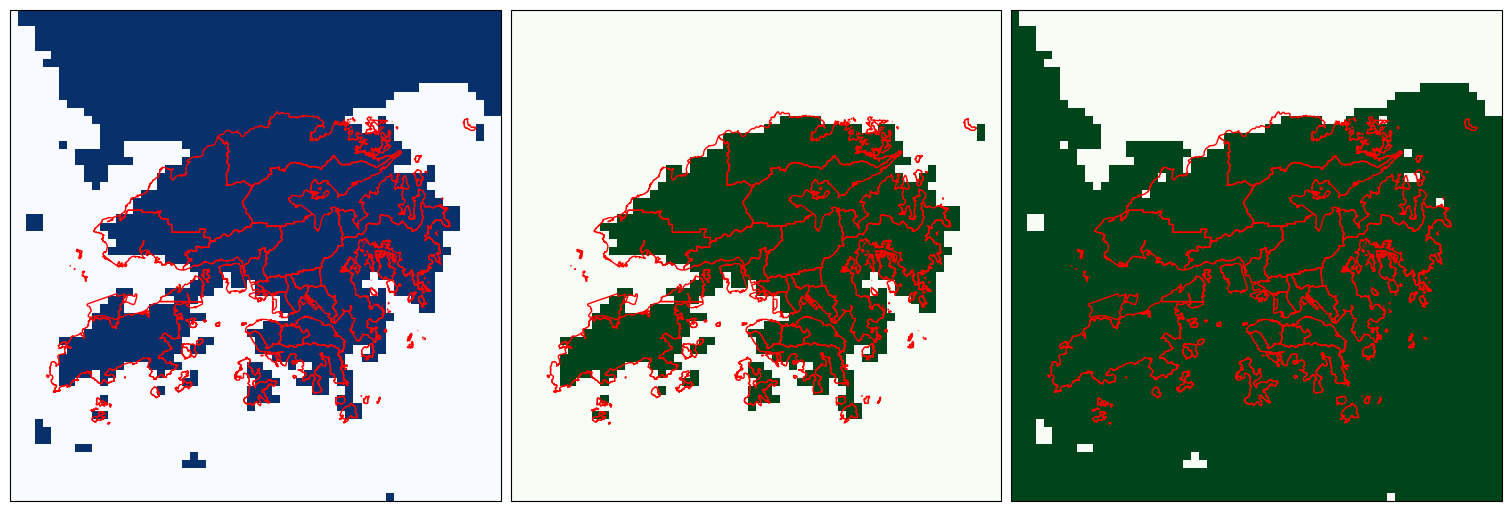

In [12]:
# Choose a projection (PlateCarree is good for lat/lon)
proj = ccrs.PlateCarree()

fig, axes = plt.subplots(
    1, 3, figsize=(15, 5), subplot_kw={"projection": proj}, constrained_layout=True
)

axes[0].pcolormesh(lon_grid, lat_grid, ds_domain['mask'], transform=proj, cmap='Blues', shading='auto')
axes[1].pcolormesh(lon_grid, lat_grid, ds_domain_mask_modified['mask_modified'], transform=proj, cmap='Greens', shading='auto')
axes[2].pcolormesh(lon_grid, lat_grid, ds_domain_mask_modified['mask_modified'].values - ds_domain['mask'].values, transform=proj, cmap='Greens', shading='auto')
# Optional: add coastlines for context
for ax in axes:
    #ax.coastlines()
    #ax.gridlines(draw_labels=True)
    gdf_hk.boundary.plot(ax=ax, edgecolor="red", linewidth=1, transform=proj)
plt.show()

In [24]:
pct_urban_hk = ds_surf['PCT_URBAN'].sum(dim='numurbl').where(ds_domain_mask_modified['mask_modified'])
pct_urban_hk_modified = pct_urban_hk.where(ds_domain_mask_modified['mask_modified'])/100
ds_domain_mask_output = xr.Dataset(
    {'mask': (['lsmlat', 'lsmlon'], ds_domain_mask_modified['mask_modified'].values),
     'PCT_URBAN': (['lsmlat', 'lsmlon'], pct_urban_hk_modified.values)},
    coords={'lsmlat': ds_domain_mask_modified['lsmlat'], 'lsmlon': ds_domain_mask_modified['lsmlon']}
)
ds_domain_mask_output

<xarray.Dataset> Size: 33kB
Dimensions:    (lsmlat: 60, lsmlon: 60)
Coordinates:
  * lsmlat     (lsmlat) int64 480B 0 1 2 3 4 5 6 7 8 ... 52 53 54 55 56 57 58 59
  * lsmlon     (lsmlon) int64 480B 0 1 2 3 4 5 6 7 8 ... 52 53 54 55 56 57 58 59
Data variables:
    mask       (lsmlat, lsmlon) bool 4kB False False False ... False False False
    PCT_URBAN  (lsmlat, lsmlon) float64 29kB nan nan nan nan ... nan nan nan nan

In [25]:
ds_domain_mask_output_lat_lon = xr.Dataset(
    {'mask': (['lat', 'lon'], ds_domain_mask_modified['mask_modified'].values),
     'PCT_URBAN': (['lat', 'lon'], pct_urban_hk_modified.values)},
    coords={'lat': lat, 'lon': lon}
)
ds_domain_mask_output_lat_lon

<xarray.Dataset> Size: 33kB
Dimensions:    (lat: 60, lon: 60)
Coordinates:
  * lat        (lat) float64 480B 22.06 22.07 22.08 22.09 ... 22.67 22.68 22.69
  * lon        (lon) float64 480B 113.8 113.8 113.8 113.8 ... 114.4 114.5 114.5
Data variables:
    mask       (lat, lon) bool 4kB False False False False ... False False False
    PCT_URBAN  (lat, lon) float64 29kB nan nan nan nan nan ... nan nan nan nan

<Axes: >

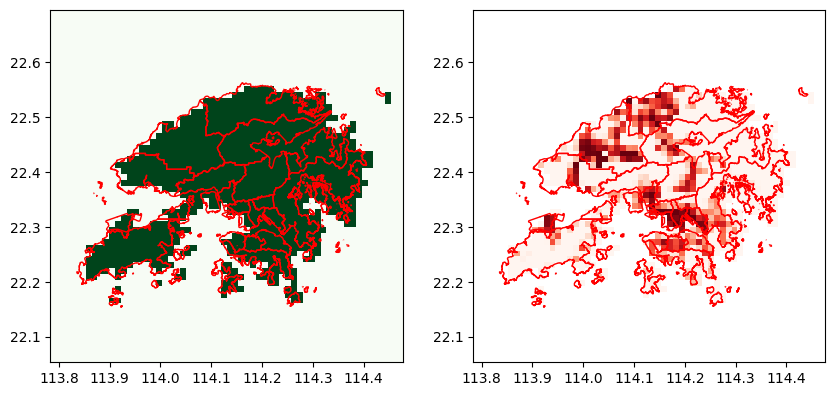

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# mask
axes[0].pcolormesh(lon_grid, lat_grid, ds_domain_mask_output['mask'], cmap='Greens', shading='auto')
gdf_hk.boundary.plot(ax=axes[0], edgecolor="red", linewidth=1)

# PCT_URBAN
axes[1].pcolormesh(lon_grid, lat_grid, ds_domain_mask_output['PCT_URBAN'], cmap='Reds', shading='auto')
gdf_hk.boundary.plot(ax=axes[1], edgecolor="red", linewidth=1)

In [27]:
if os.path.exists(output_filename):
    os.remove(output_filename)
ds_domain_mask_output.to_netcdf(output_filename, mode='w', format='NETCDF4')    
ds_domain_mask_output

<xarray.Dataset> Size: 33kB
Dimensions:    (lsmlat: 60, lsmlon: 60)
Coordinates:
  * lsmlat     (lsmlat) int64 480B 0 1 2 3 4 5 6 7 8 ... 52 53 54 55 56 57 58 59
  * lsmlon     (lsmlon) int64 480B 0 1 2 3 4 5 6 7 8 ... 52 53 54 55 56 57 58 59
Data variables:
    mask       (lsmlat, lsmlon) bool 4kB False False False ... False False False
    PCT_URBAN  (lsmlat, lsmlon) float64 29kB nan nan nan nan ... nan nan nan nan

In [28]:
if os.path.exists(output_filename_lat_lon):
    os.remove(output_filename_lat_lon)
ds_domain_mask_output_lat_lon.to_netcdf(output_filename_lat_lon, mode='w', format='NETCDF4')    
ds_domain_mask_output_lat_lon

<xarray.Dataset> Size: 33kB
Dimensions:    (lat: 60, lon: 60)
Coordinates:
  * lat        (lat) float64 480B 22.06 22.07 22.08 22.09 ... 22.67 22.68 22.69
  * lon        (lon) float64 480B 113.8 113.8 113.8 113.8 ... 114.4 114.5 114.5
Data variables:
    mask       (lat, lon) bool 4kB False False False False ... False False False
    PCT_URBAN  (lat, lon) float64 29kB nan nan nan nan nan ... nan nan nan nan